In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

import xgboost as xgb

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# Data Loading


In [2]:
df = pd.read_csv('../data/Loan_data.csv')

In [3]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


# Preprocessing

#### Détection des valeurs manquantes:

In [5]:
nans = df.isna().sum(axis=0)
print(nans.sum())

0


Pas de valeurs manquantes, pas besoin de les traiter.

#### Traitement des dates

In [6]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month
df['ApplicationDay'] = df['ApplicationDate'].dt.day
df = df.drop('ApplicationDate', axis=1)

### Séparation des variables numériques et catégorielles

In [7]:
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_vars_count = {col: df[col].nunique() for col in categorical_vars}

In [8]:
print('Variables numériques:', numerical_vars)
print('Variables catégorielles:', categorical_vars_count)

Variables numériques: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay']
Variables catégorielles: {'EmploymentStatus': 3, 'EducationLevel': 5, 'MaritalStatus': 4, 'HomeOwnershipStatus': 4, 'LoanPurpose': 5}


#### Encodage des variables catégorielles (one-hot encoding)

In [9]:
drop = 'first'
encoder = OneHotEncoder(sparse_output=False, drop=drop)
encoded = encoder.fit_transform(df[list(categorical_vars_count.keys())])
encoded_categorical_vars = encoder.get_feature_names_out(list(categorical_vars_count.keys()))
encoded_df = pd.DataFrame(encoded, columns=encoded_categorical_vars)

In [10]:
encoded_df = df[numerical_vars].join(encoded_df)

In [11]:
encoded_df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Analyse exploratoire des données

#### Matrice de corrélation des variables numériques

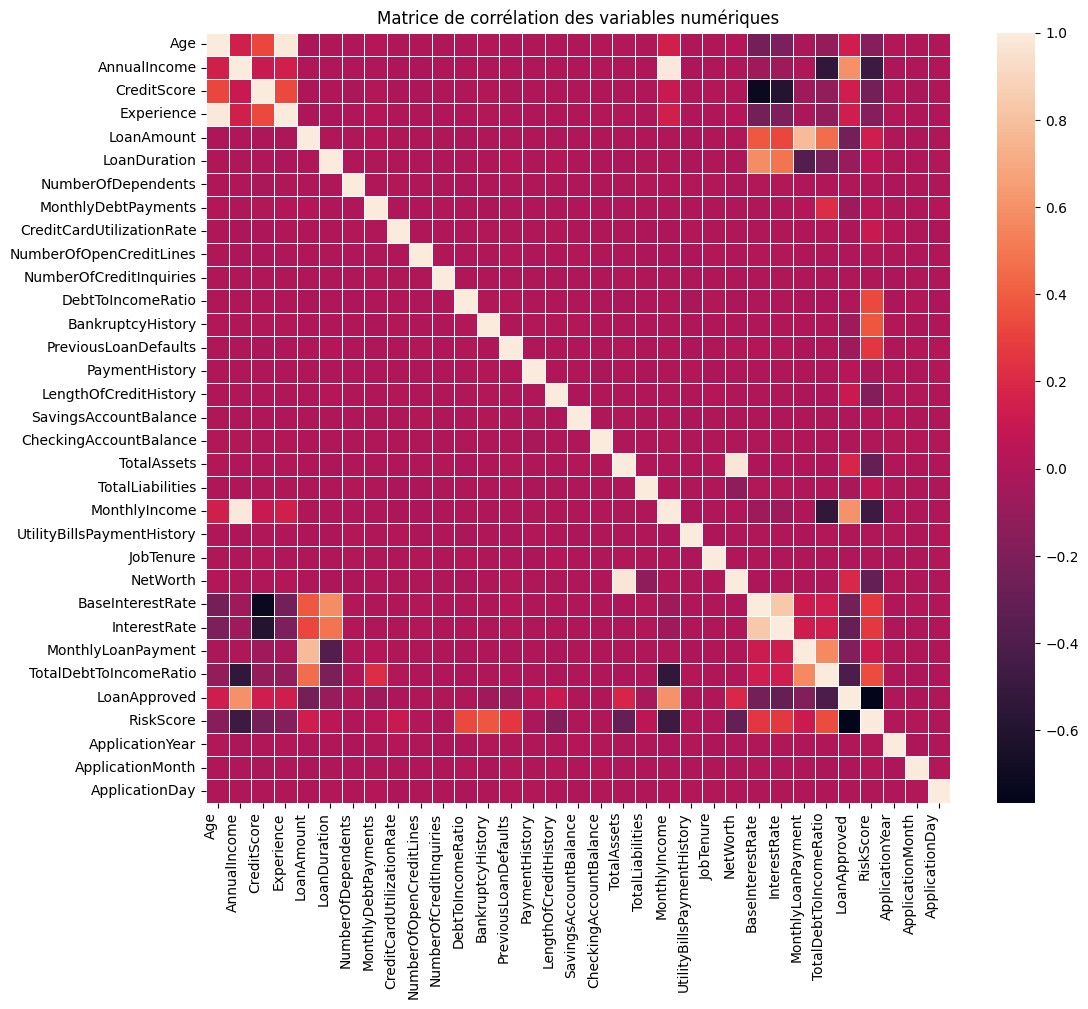

In [12]:
plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df[numerical_vars].corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)    
plt.title('Matrice de corrélation des variables numériques')          

plt.show()


#### Matrice de corrélations des variables catégorielles (après encodage)

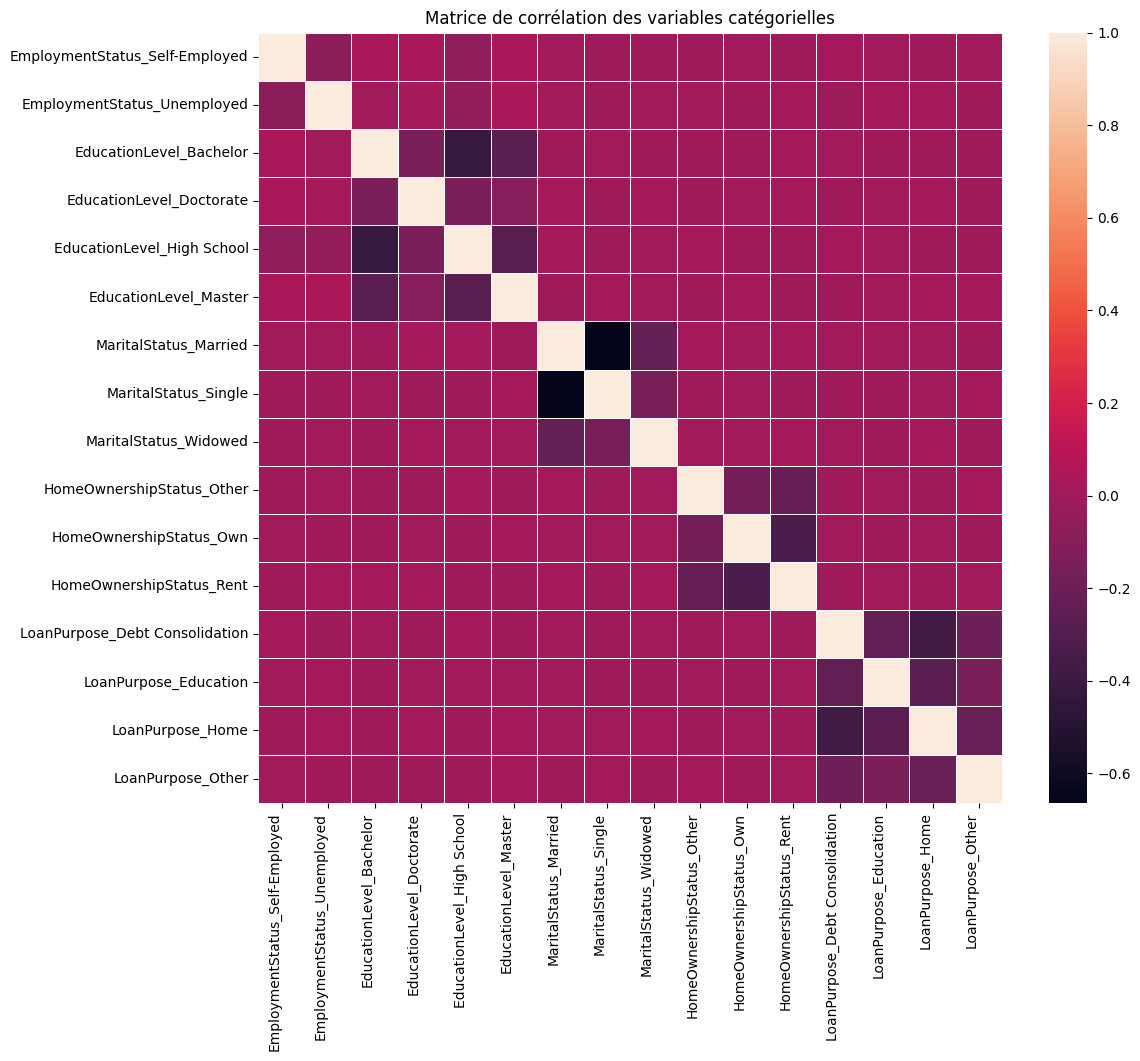

In [13]:

plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df[encoded_categorical_vars].corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)              
plt.title('Matrice de corrélation des variables catégorielles')
plt.show()


In [14]:
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()

categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_vars_count = {col: df[col].nunique() for col in categorical_vars}
print('Variables numériques:', numerical_vars)
print('Variables catégorielles:', categorical_vars_count)

Variables numériques: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay']
Variables catégorielles: {'EmploymentStatus': 3, 'EducationLevel': 5, 'MaritalStatus': 4, 'HomeOwnershipStatus': 4, 'LoanPurpose': 5}


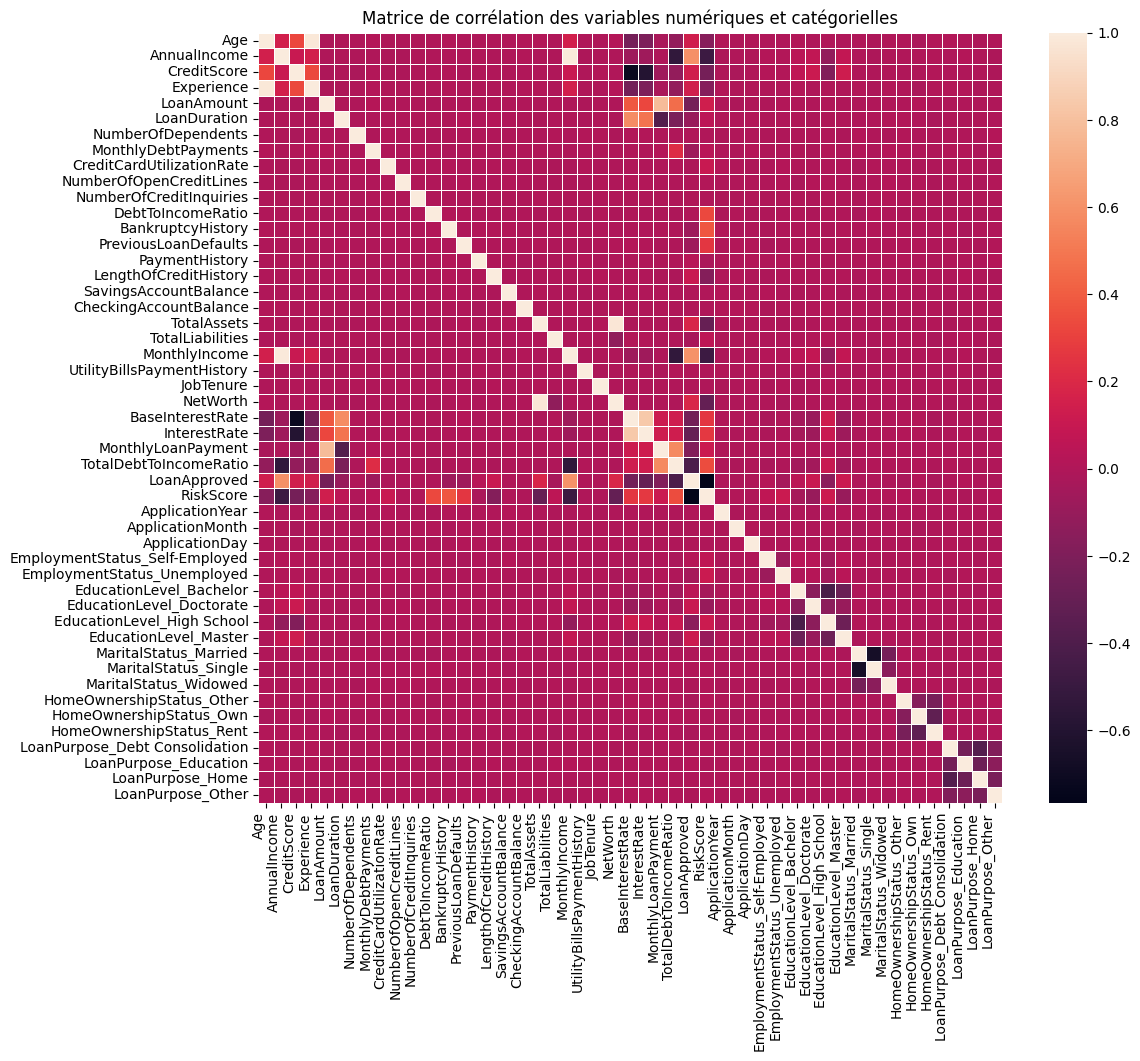

In [15]:

plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df.corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)              
plt.title('Matrice de corrélation des variables numériques et catégorielles')
plt.show()

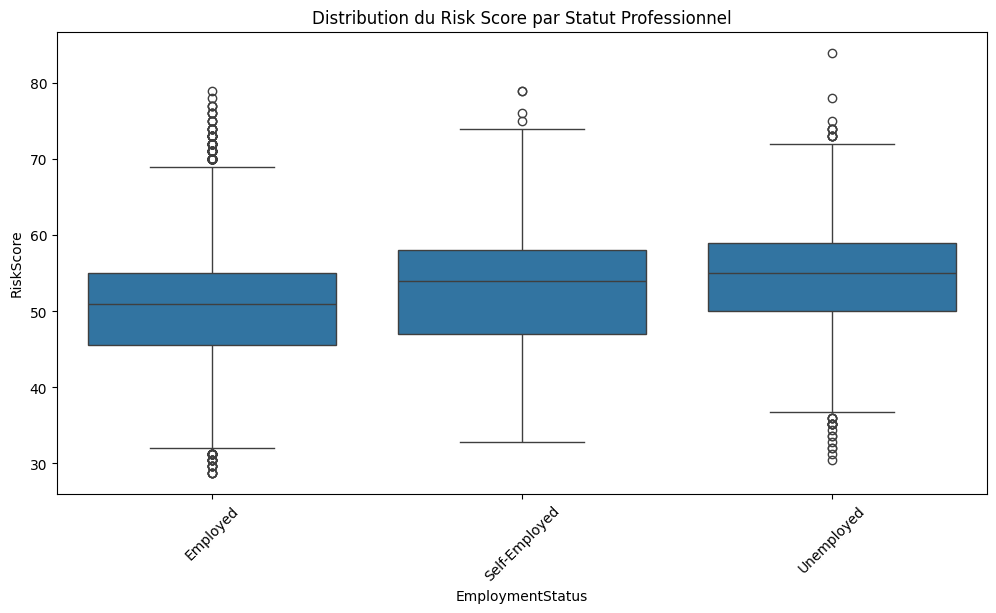

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='EmploymentStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut Professionnel')
plt.show()

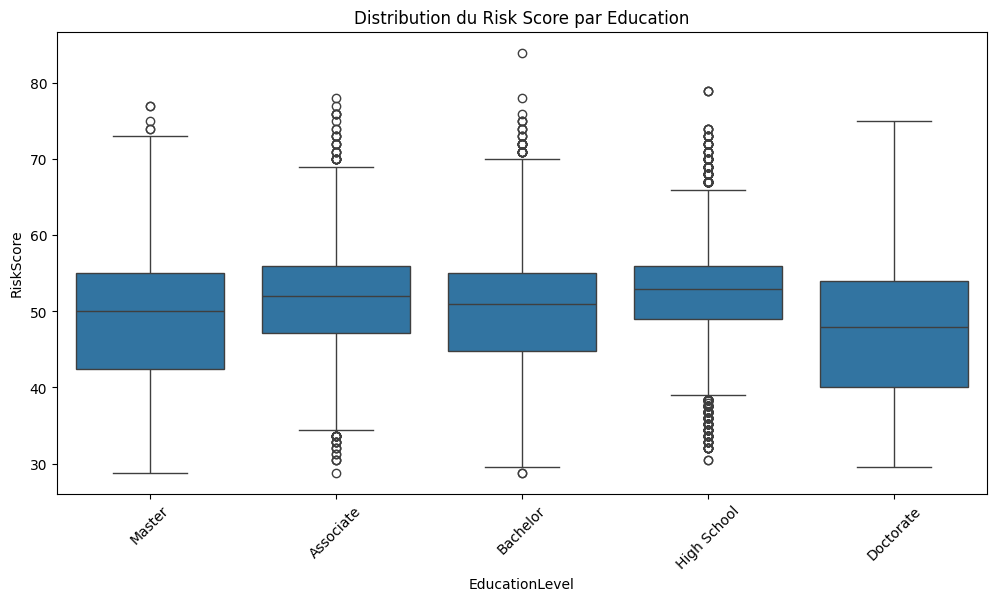

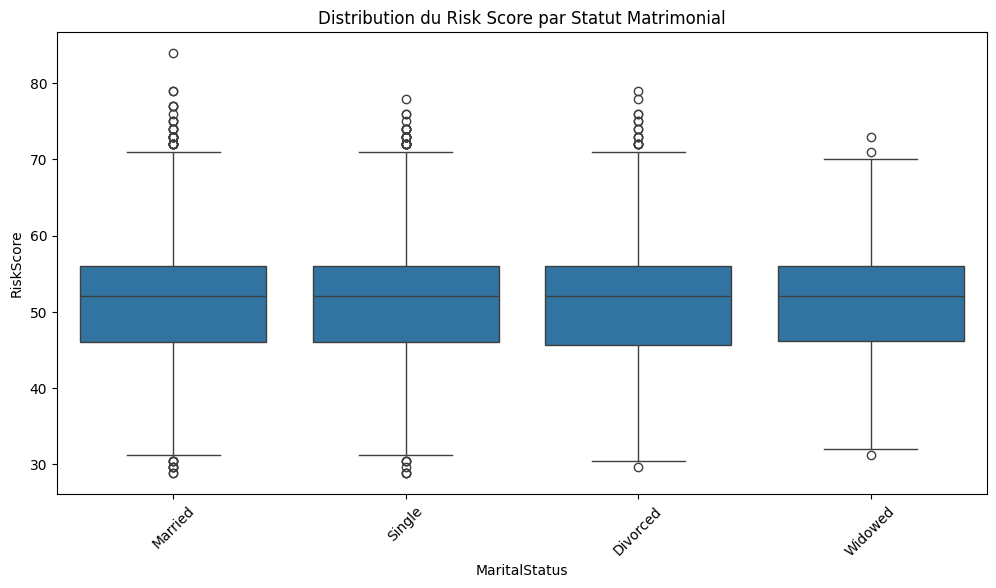

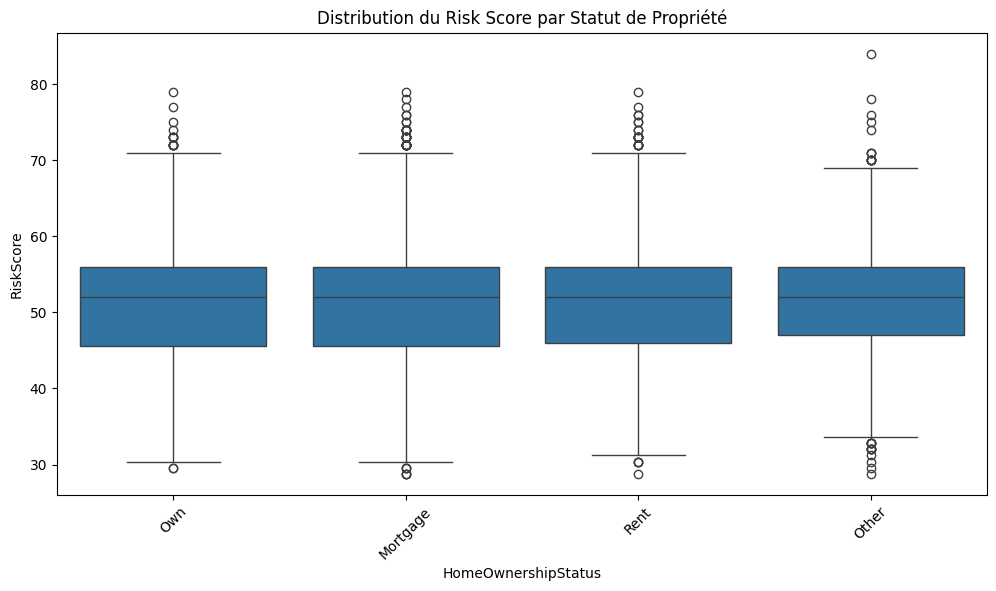

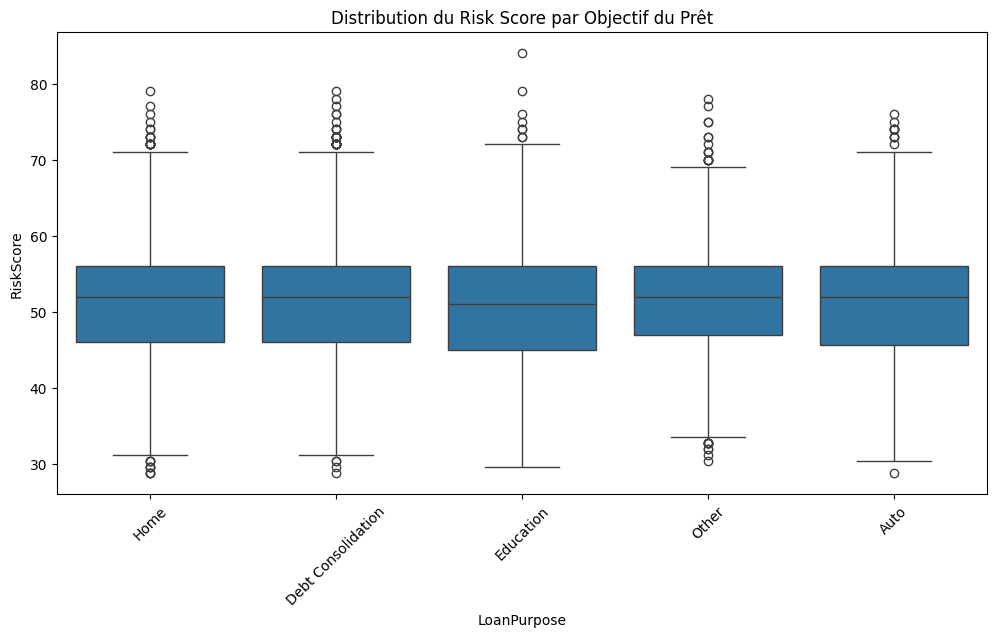

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='EducationLevel', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Education')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='MaritalStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut Matrimonial')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='HomeOwnershipStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut de Propriété')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='LoanPurpose', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Objectif du Prêt')
plt.show()


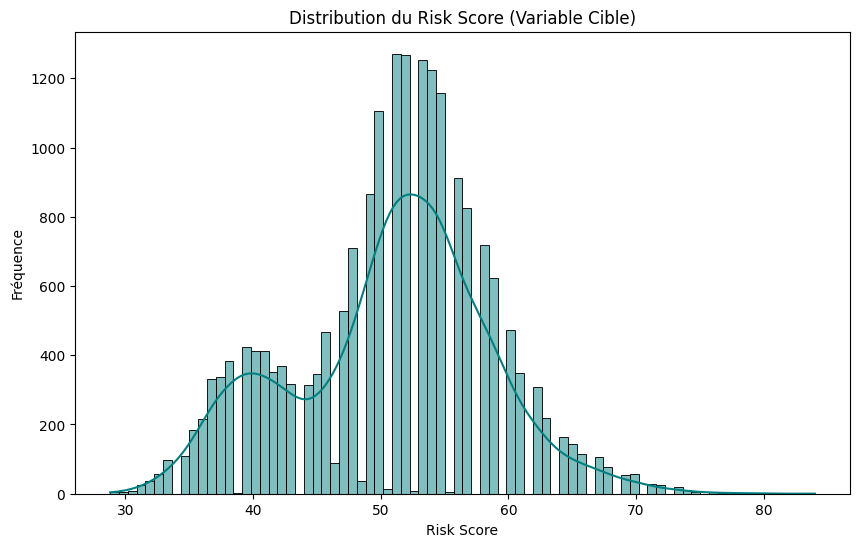

In [18]:

plt.figure(figsize=(10, 6))
sns.histplot(df['RiskScore'], kde=True, bins=80, color='teal')
plt.title('Distribution du Risk Score (Variable Cible)')
plt.xlabel('Risk Score')
plt.ylabel('Fréquence')
plt.show()

# Feature engineering


In [19]:
#  Transformations Logarithmiques pour réduire l'asymétrie 
cols_to_log = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalAssets', 'TotalLiabilities']
for col in cols_to_log:
    # On vérifie qu'il n'y a pas de valeurs négatives problématiques
    if (df[col] >= 0).all():
        df[f'Log_{col}'] = np.log1p(df[col])
        


In [20]:

# Tranches d'âge
bins = [0,18, 25, 35, 45, 55, 65, 100]
labels = ['0-18','18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [21]:
# Total Cash 
df['Total_Cash'] = df['SavingsAccountBalance'] + df['CheckingAccountBalance']

# Ratio de couverture du prêt par le cash
df['Cash_to_Loan_Ratio'] = df['Total_Cash'] / (df['LoanAmount'] + 1)

# Ratio Épargne / Revenu Annuel 
df['Savings_to_Income'] = df['Total_Cash'] / (df['AnnualIncome'] + 1)


#  Ratio d'endettement global
df['Global_Debt_Ratio'] = df['TotalLiabilities'] / (df['TotalAssets'] + 1)

# Poids du prêt demandé par rapport au revenu annuel
df['Loan_to_Income'] = df['LoanAmount'] / (df['AnnualIncome'] + 1)


# Revenu mensuel - Dettes mensuelles actuelles - Futur paiement du prêt
df['Free_Cash_Flow'] = df['MonthlyIncome'] - df['MonthlyDebtPayments'] - df['MonthlyLoanPayment']

# Reste à vivre par personne
df['Income_Per_Capita'] = df['Free_Cash_Flow'] / (df['NumberOfDependents'] + 1)

# Spread de taux 
# Si c'est élevé, l'analyste humain ou le système précédent a déjà vu un risque.
df['Interest_Spread'] = df['InterestRate'] - df['BaseInterestRate']

In [22]:
#count nan
df.isna().sum()

Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
InterestRate                  0
MonthlyL

On refait le one-hot encodding

In [23]:
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()

categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_vars_count = {col: df[col].nunique() for col in categorical_vars}
print('Variables numériques:', numerical_vars)
print('Variables catégorielles:', categorical_vars_count)

Variables numériques: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay', 'Log_AnnualIncome', 'Log_LoanAmount', 'Log_NetWorth', 'Log_TotalAssets', 'Log_TotalLiabilities', 'Total_Cash', 'Cash_to_Loan_Ratio', 'Savings_to_Income', 'Global_Debt_Ratio', 'Loan_to_Income', 'Free_Cash_Flow', 'Income_Per_Capita', 'Interest_Spread']
Variables catégorielles: {'EmploymentStatus': 3, 'EducationLevel': 5, 'MaritalS

In [24]:
drop = 'first'
encoder = OneHotEncoder(sparse_output=False, drop=drop)
encoded = encoder.fit_transform(df[list(categorical_vars_count.keys())])
encoded_categorical_vars = encoder.get_feature_names_out(list(categorical_vars_count.keys()))
encoded_df = pd.DataFrame(encoded, columns=encoded_categorical_vars)
encoded_df = df[numerical_vars].join(encoded_df)

In [25]:
encoded_df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,AgeGroup_18-25,AgeGroup_26-35,AgeGroup_36-45,AgeGroup_46-55,AgeGroup_56-65,AgeGroup_65+
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Entraînement des modèles


### Division train test

In [26]:

non_train_col = ['LoanApproved', 'RiskScore']

X_train, X_test, y_train, y_test = train_test_split(encoded_df.drop(columns=non_train_col), encoded_df['RiskScore'], test_size=0.2, random_state=1)

### Baseline: Modèle trivial et régression linéaire

 "Modèle" aléatoire

In [27]:
y_pred = pd.DataFrame(data=np.random.normal(df['RiskScore'].mean(), df['RiskScore'].std(), size=y_test.shape), index=y_test.index)

In [28]:
print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred):.4f}")

RMSE final sur Test : 10.8067
R² final sur Test   : -0.9457


Régression linéaire

In [29]:
from sklearn.linear_model import LinearRegression

# on scale pour la régression linéaire
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear_regressor = LinearRegression().fit(X_train_scaled, y_train)

y_pred_lr = linear_regressor.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Métriques sur X_test ---")
print(f"RMSE : {rmse_lr:.4f}") 
print(f"MAE  : {mae_lr:.4f}")   
print(f"R²   : {r2_lr:.4f}")    


--- Métriques sur X_test ---
RMSE : 3.3481
MAE  : 2.6835
R²   : 0.8132


### CART

In [30]:


cart_regressor = DecisionTreeRegressor(random_state=1)

param_grid = {
    'max_depth': [3, 5, 8, 12],            
    'min_samples_split': [2, 10, 20],      # Limiter les divisions trop fines
    'min_samples_leaf': [1, 5, 10, 20],     # évite les valeurs extrêmes isolées
    'max_features': [None, 'sqrt', 'log2'],
}


In [31]:

cv = KFold(n_splits=5, shuffle=True, random_state=1)


grid_search_cart = GridSearchCV(
    estimator=cart_regressor,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search_cart.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search_cart.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search_cart.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits


c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Meilleurs paramètres : {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Meilleur RMSE (CV) : 3.6763


In [32]:

best_cart = grid_search_cart.best_estimator_
y_pred_cart = best_cart.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred_cart)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred_cart):.4f}")

RMSE final sur Test : 3.5590
R² final sur Test   : 0.7890


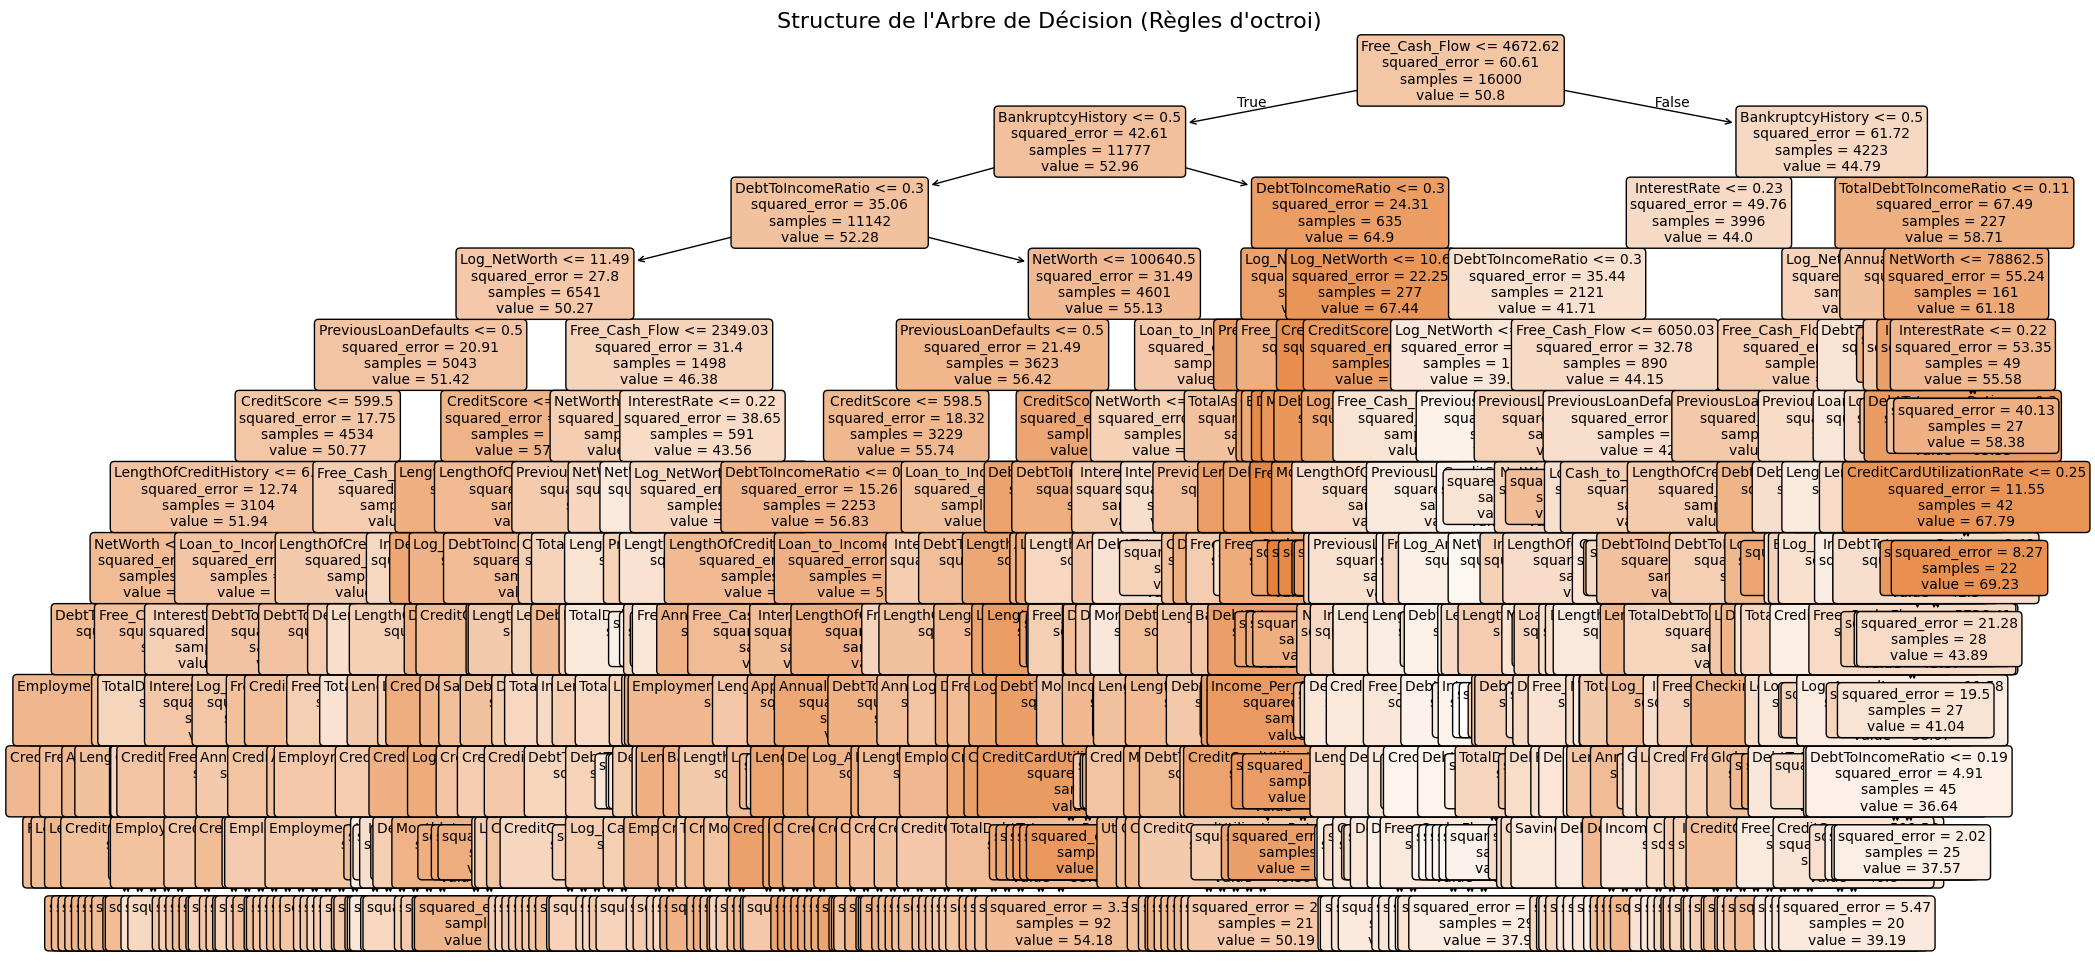

In [33]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

plt.figure(figsize=(24, 12))  
plot_tree(
    best_cart, 
    feature_names=X_train.columns, 
    filled=True,            
    rounded=True,          
    fontsize=10,
    precision=2
)
plt.title("Structure de l'Arbre de Décision (Règles d'octroi)", fontsize=16)
plt.show()



c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


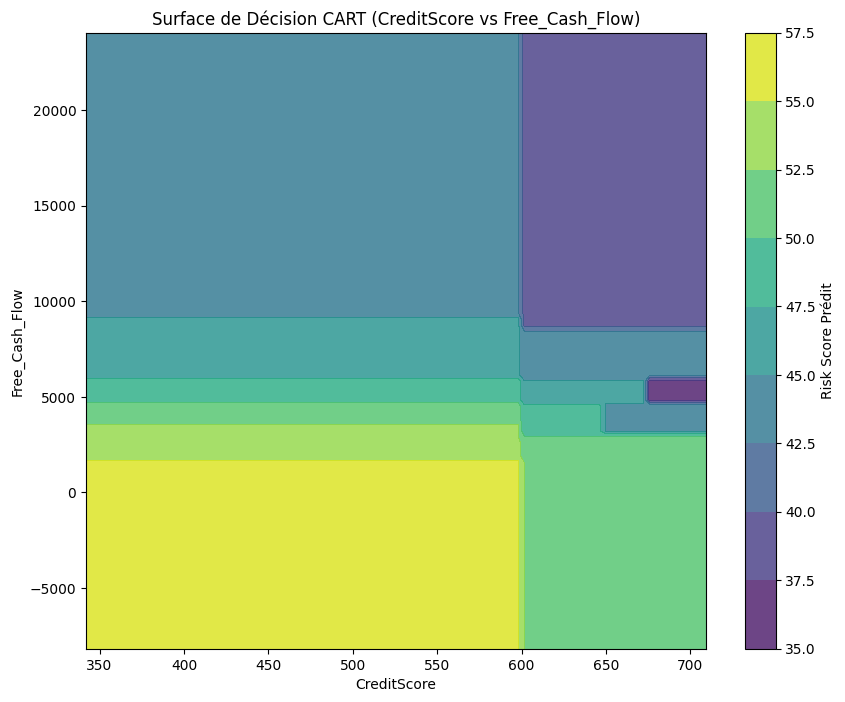

In [34]:
feat_1 = 'CreditScore'
feat_2 = 'Free_Cash_Flow' 

if feat_1 in X_train.columns and feat_2 in X_train.columns:
    X_2d = X_train[[feat_1, feat_2]]
    

    cart_2d = DecisionTreeRegressor(max_depth=4, random_state=42)
    cart_2d.fit(X_2d, y_train)

    x_min, x_max = X_2d[feat_1].min() - 1, X_2d[feat_1].max() + 1
    y_min, y_max = X_2d[feat_2].min() - 1, X_2d[feat_2].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max-x_min)/100),
                         np.arange(y_min, y_max, (y_max-y_min)/100))

    # Prédiction sur la grile
    Z = cart_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(10, 8))
    contour = plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis') # Viridis : Jaune=Haut Risque, Violet=Bas Risque (ou inverse selon data)
    plt.colorbar(contour, label='Risk Score Prédit')
    plt.xlabel(feat_1)
    plt.ylabel(feat_2)
    plt.title(f'Surface de Décision CART ({feat_1} vs {feat_2})')
    plt.show()
else:
    print(f"Les colonnes {feat_1} ou {feat_2} ne sont pas trouvées pour le graphe 2D.")

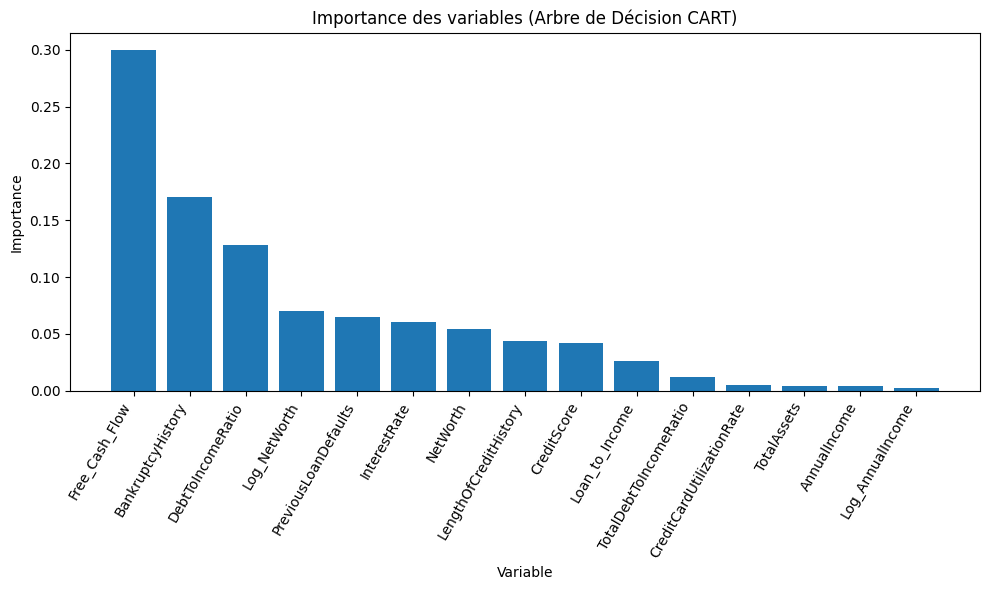

In [35]:
# Affichage des importances des variables pour le modèle CART déjà entraîné

importances = best_cart.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15 if len(indices) > 15 else len(indices)

plt.figure(figsize=(10, 6))
plt.title("Importance des variables (Arbre de Décision CART)")
plt.bar(range(top_n), importances[indices][:top_n], align="center")
plt.xticks(range(top_n), np.array(X_train.columns)[indices][:top_n], rotation=60, ha='right')
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()




### Random Forest

In [36]:

rf_regressor = RandomForestRegressor(random_state=1,n_jobs=-1)




In [37]:
param_grid = {
    'max_depth': [3, 5, 8, 12],
    'min_samples_split': [2, 10, 20],   
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': [1/3, 'sqrt', 'log2']
}



In [38]:

cv = KFold(n_splits=5, shuffle=True, random_state=1)

grid_search_rf = GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search_rf.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.4s
[CV] END max_d

c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Meilleurs paramètres : {'max_depth': 12, 'max_features': 0.3333333333333333, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur RMSE (CV) : 3.0135


In [39]:




best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred_rf):.4f}")

RMSE final sur Test : 2.9595
R² final sur Test   : 0.8541


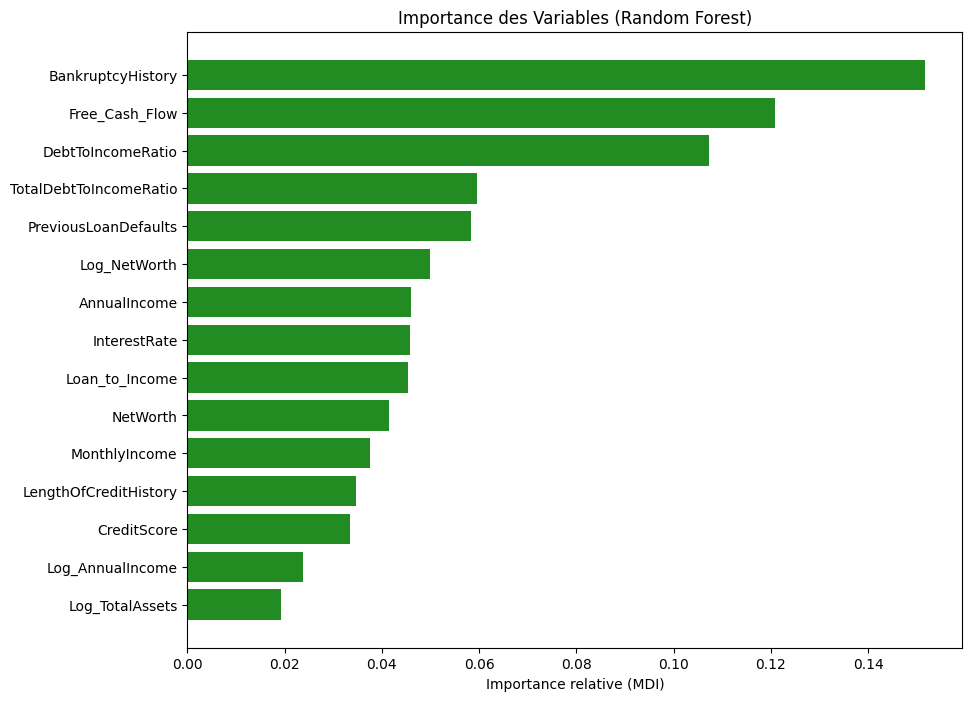

In [40]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# ==========================================
# GRAPHE 2 : FEATURE IMPORTANCE (Spécifique RF)
# ==========================================
# On utilise le modèle final (celui avec 300 arbres issus de la boucle)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15

plt.figure(figsize=(10, 8))
plt.title('Importance des Variables (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Importance relative (MDI)')
plt.show()

XGBoost

In [41]:


xgb.set_config(verbosity=2)

device = 'cuda'

xgb_regressor = xgb.XGBRegressor(tree_method='hist', device = device)


In [42]:

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'n_estimators': [500, 1000],
    "subsample": [0.7, 1.0],        
    "colsample_bytree": [0.7, 1.0],
    
    "min_child_weight": [1, 5, 10], 
    "reg_lambda": [1, 5, 10],    
    "reg_alpha": [0, 0.1, 1.0],     
}




In [43]:

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_regressor,
    param_distributions=param_grid,
    n_iter=40,
    # n_iter=10,                       
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,         
    verbose=2,
    random_state=1
)
random_search_xgb.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {random_search_xgb.best_params_}")
print(f"Meilleur RMSE (CV) : {-random_search_xgb.best_score_:.4f}")


Fitting 3 folds for each of 40 candidates, totalling 120 fits
[15:42:18] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10666, 66, 703956).
[15:42:18] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.


c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [15:42:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=0.7; total time=   6.4s
[15:42:24] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10667, 66, 704022).
[15:42:24] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=0.7; total time=   5.6s
[15:42:30] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10667, 66, 704022).
[15:42:30] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=

In [44]:

best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred_xgb):.4f}")


RMSE final sur Test : 2.2196
R² final sur Test   : 0.9179


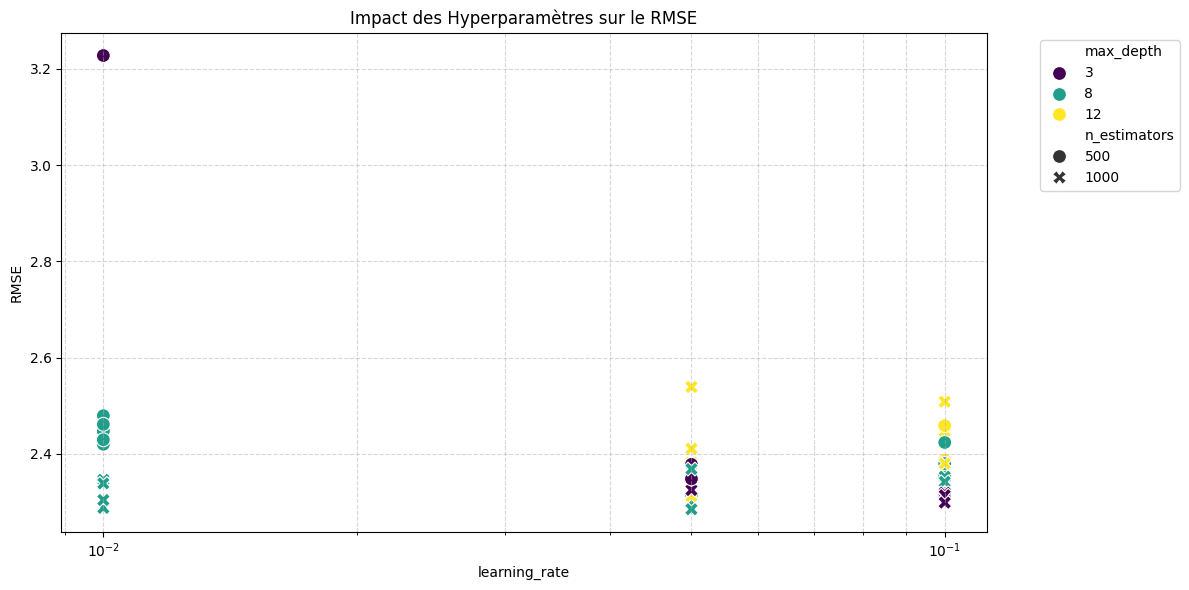

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# On récupère les résultats du RandomSearch dans un DataFrame
results_df = pd.DataFrame(random_search_xgb.cv_results_)

# On nettoie les noms de colonnes pour l'affichage (supprime le préfixe 'param_')
cols = [col for col in results_df.columns if col.startswith('param_')]
rename_map = {col: col.replace('param_', '') for col in cols}
results_df = results_df.rename(columns=rename_map)

# On convertit le score négatif en RMSE positif
results_df['RMSE'] = -results_df['mean_test_score']

# GRAPHE : Impact du Learning Rate et de la Profondeur
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=results_df, 
    x='learning_rate', 
    y='RMSE', 
    hue='max_depth', 
    palette='viridis', 
    s=100, # Taille des points
    style='n_estimators' # Forme des points selon le nombre d'arbres
)
plt.title('Impact des Hyperparamètres sur le RMSE')
plt.xscale('log') # Souvent mieux pour le learning rate
plt.ylabel('RMSE')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

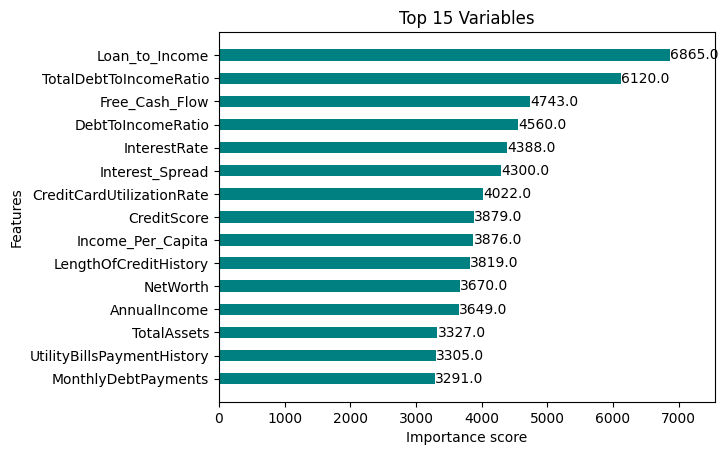

In [46]:
from xgboost import plot_importance


plt.figure(figsize=(12, 10))
# Importance type 'gain' = apport moyen d'information de la variable
plot_importance(
    best_xgb, 
    max_num_features=15, 
    height=0.5, 
    title='Top 15 Variables',
    color='teal',
    grid=False
)
plt.show()

--- Performance du Modèle Final ---


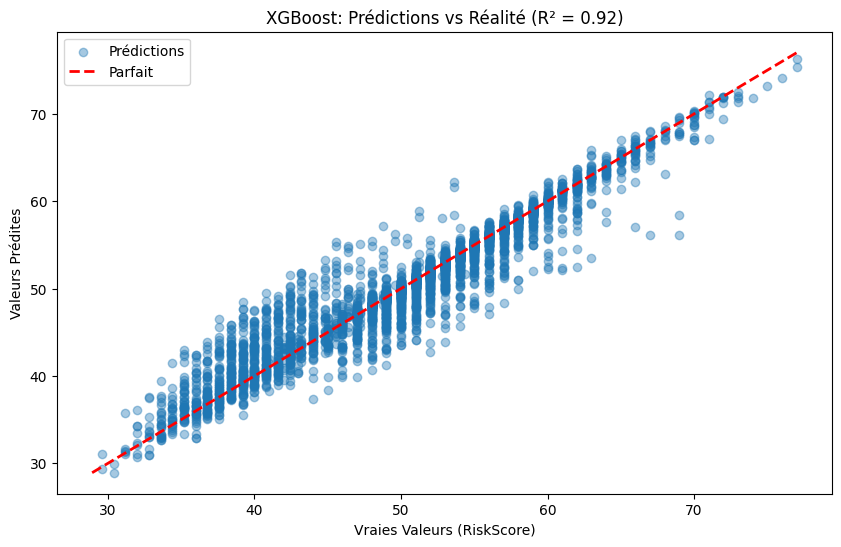

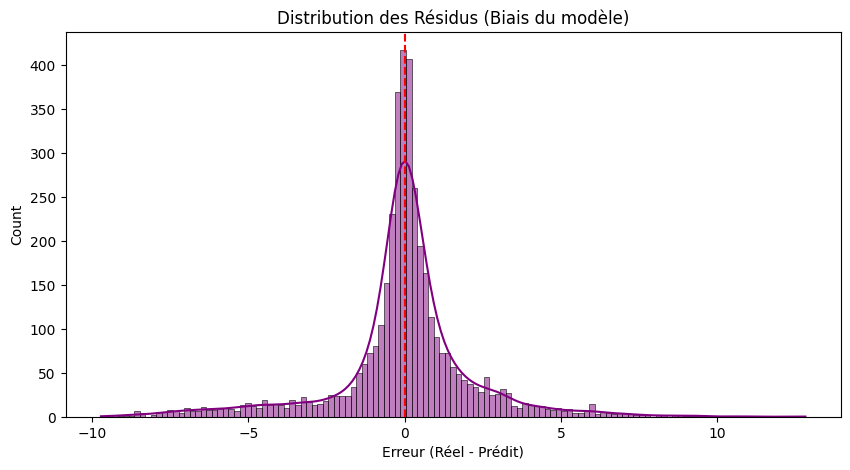

In [47]:
print("--- Performance du Modèle Final ---")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='#1f77b4', label='Prédictions')

# Ligne de perfection
min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Parfait')

plt.xlabel('Vraies Valeurs (RiskScore)')
plt.ylabel('Valeurs Prédites')
plt.title(f'XGBoost: Prédictions vs Réalité (R² = {r2_score(y_test, y_pred_xgb):.2f})')
plt.legend()
plt.show()

# Distribution des erreurs
residuals = y_test - y_pred_xgb
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution des Résidus (Biais du modèle)')
plt.xlabel('Erreur (Réel - Prédit)')
plt.axvline(0, color='red', linestyle='--')
plt.show()

--- Analyse SHAP (Interprétabilité Globale) ---


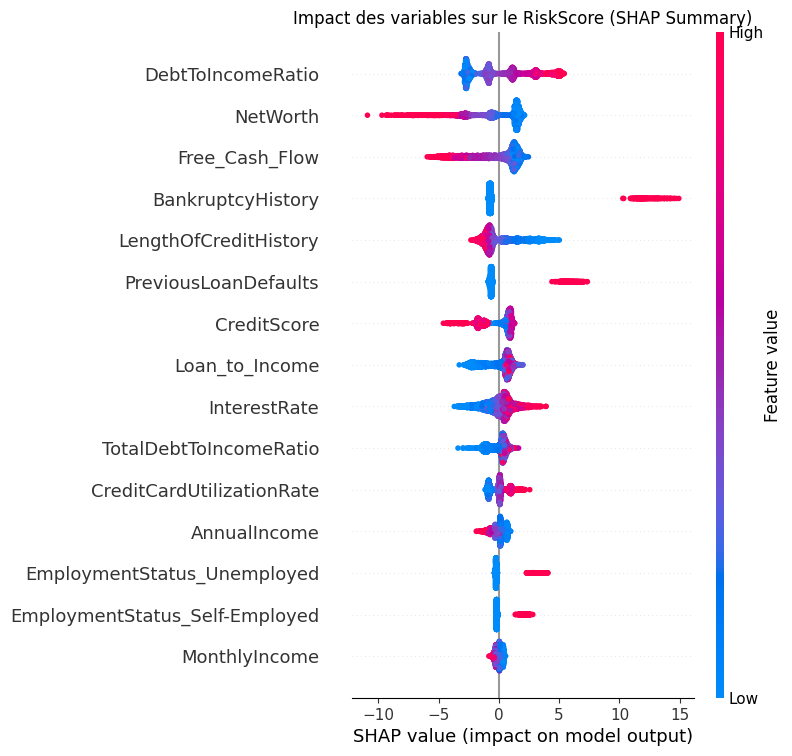

In [48]:
import shap

# Initialisation (XGBoost est très rapide avec TreeExplainer)
# Note : Si erreur CUDA, essayez de passer le modèle en CPU avant, 
# ou utilisez X_test version CPU (pandas dataframe)
print("--- Analyse SHAP (Interprétabilité Globale) ---")

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("Impact des variables sur le RiskScore (SHAP Summary)")
plt.show()

### CAT Boost

In [49]:
# on utilise pas le encoded ici car catboost gère les catégorielles nativement

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=non_train_col), df['RiskScore'], test_size=0.2, random_state=1)

In [50]:
cat_vars = list(categorical_vars_count.keys())
print(cat_vars)
cat_model = CatBoostRegressor(
    task_type="GPU", devices="0",
    verbose=0,              
    cat_features=cat_vars,
    loss_function='RMSE',   
    thread_count=-1,
    early_stopping_rounds=50,
    random_state=1
)


['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'AgeGroup']


In [51]:

param_grid = {
    'depth': [4, 8,12],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000],
    'l2_leaf_reg': [1, 3, 5],
}
# param_grid = {
#     'depth': [4],
#     'learning_rate': [ 0.1],
#     'iterations': [500],
#     'l2_leaf_reg': [3, 5],
# }




In [ ]:

# 4. Configurer le GridSearch
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', 
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search.best_score_:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=  13.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=  11.3s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=  11.4s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=  11.2s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=  11.3s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=  11.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=  11.1s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=  11.3s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=  11.5s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=  11.3s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rat

In [ ]:

best_catboost = grid_search.best_estimator_

y_pred_catB = best_catboost.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_catB))
mae = mean_absolute_error(y_test, y_pred_catB)
r2 = r2_score(y_test, y_pred_catB)


print("\n--- Métriques sur X_test ---")
print(f"RMSE : {rmse:.4f}") 
print(f"MAE  : {mae:.4f}")   
print(f"R²   : {r2:.4f}")    

[45.09373093 53.57236856 59.93259611 ... 52.23732487 48.33972412
 54.45072593]

--- Métriques sur X_test ---
RMSE : 2.2576
MAE  : 1.5074
R²   : 0.9151


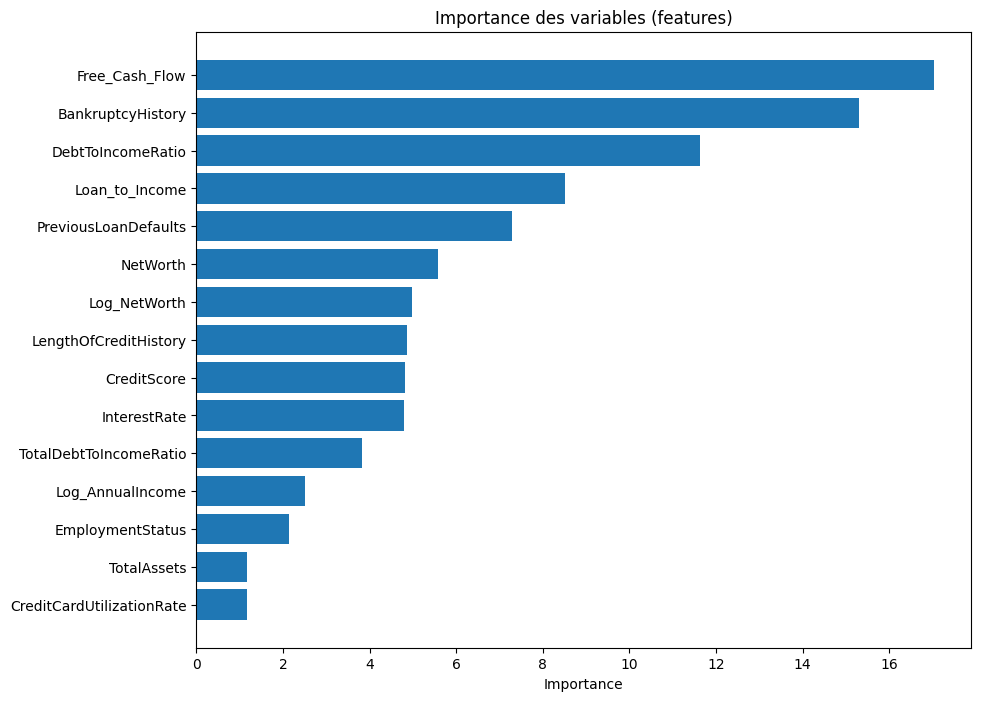

In [ ]:
# Affichage de l'importance des variables (features)
importances = best_catboost.feature_importances_ if hasattr(best_catboost, "feature_importances_") else None

if importances is not None:
    importances = np.array(importances)
    feature_names = X_train.columns
    # On sélectionne les 15 features les plus importantes
    indices = np.argsort(importances)[-15:]
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], align="center")
    plt.yticks(range(len(indices)), np.array(feature_names)[indices])
    plt.xlabel("Importance")
    plt.title("Importance des variables (features)")
    plt.show()
else:
    print("Le modèle ne fournit pas d'attribut feature_importances_.")


--- Analyse des Hyperparamètres (CatBoost) ---


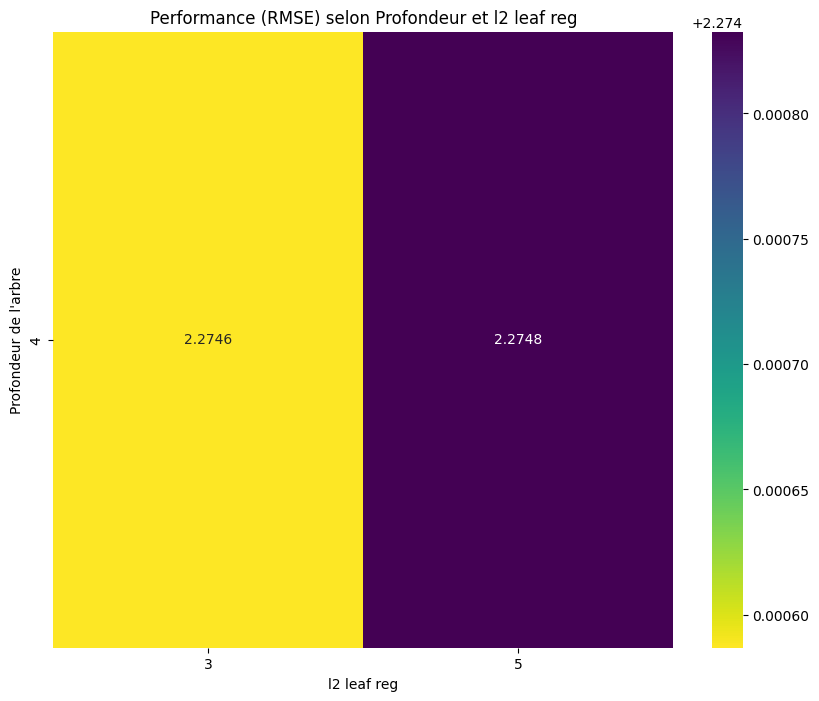

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Analyse des Hyperparamètres (CatBoost) ---")

# Récupération des résultats du GridSearch
# (Assurez-vous que 'grid_search' est bien le nom de votre objet GridSearchCV entraîné)
results_df = pd.DataFrame(grid_search.cv_results_)

# Nettoyage des noms de colonnes
cols = [col for col in results_df.columns if col.startswith('param_')]
rename_map = {col: col.replace('param_', '') for col in cols}
results_df = results_df.rename(columns=rename_map)
results_df['RMSE'] = -results_df['mean_test_score'] # On remet le score en positif

# Graphe : Heatmap ou Scatter selon le nombre de paramètres
# Ici on visualise l'impact de la Profondeur et du Learning Rate
if 'depth' in results_df.columns and 'l2_leaf_reg' in results_df.columns:
    plt.figure(figsize=(10, 8))
    
    # On pivote les données pour la heatmap
    pivot_table = results_df.pivot_table(values='RMSE', index='depth', columns='l2_leaf_reg')
    
    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis_r") # _r pour inverser (Bleu foncé = Meilleur RMSE)
    plt.title('Performance (RMSE) selon Profondeur et l2 leaf reg')
    plt.ylabel('Profondeur de l\'arbre')
    plt.xlabel('l2 leaf reg')
    plt.show()
else:
    print("Les colonnes 'depth' ou 'l2_leaf_reg' ne sont pas dans les résultats.")

--- Qualité des Prédictions ---


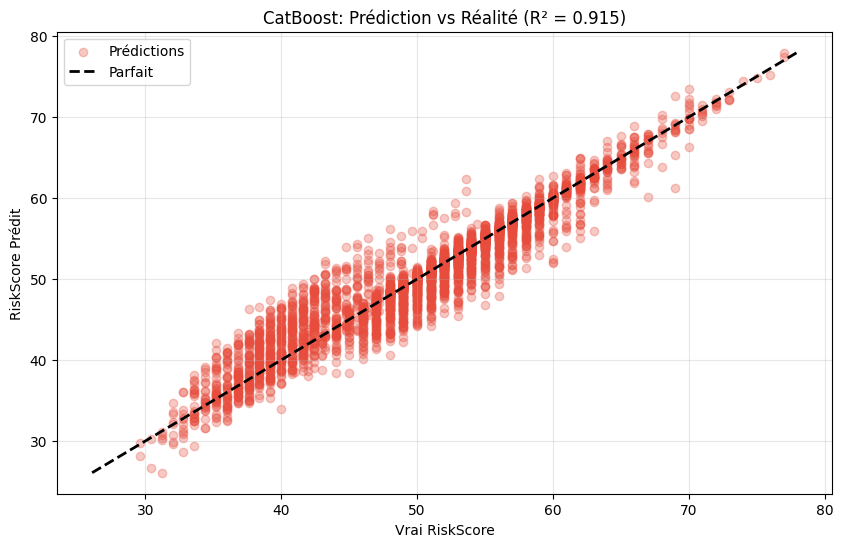

In [ ]:
from sklearn.metrics import r2_score

print("--- Qualité des Prédictions ---")

plt.figure(figsize=(10, 6))
# Nuage de points
plt.scatter(y_test, y_pred_catB, alpha=0.3, color='#e74c3c', label='Prédictions')

# Diagonale parfaite
min_val = min(y_test.min(), y_pred_catB.min())
max_val = max(y_test.max(), y_pred_catB.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Parfait')

plt.xlabel('Vrai RiskScore')
plt.ylabel('RiskScore Prédit')
plt.title(f'CatBoost: Prédiction vs Réalité (R² = {r2_score(y_test, y_pred_catB):.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Analyse SHAP (Interprétabilité) ---


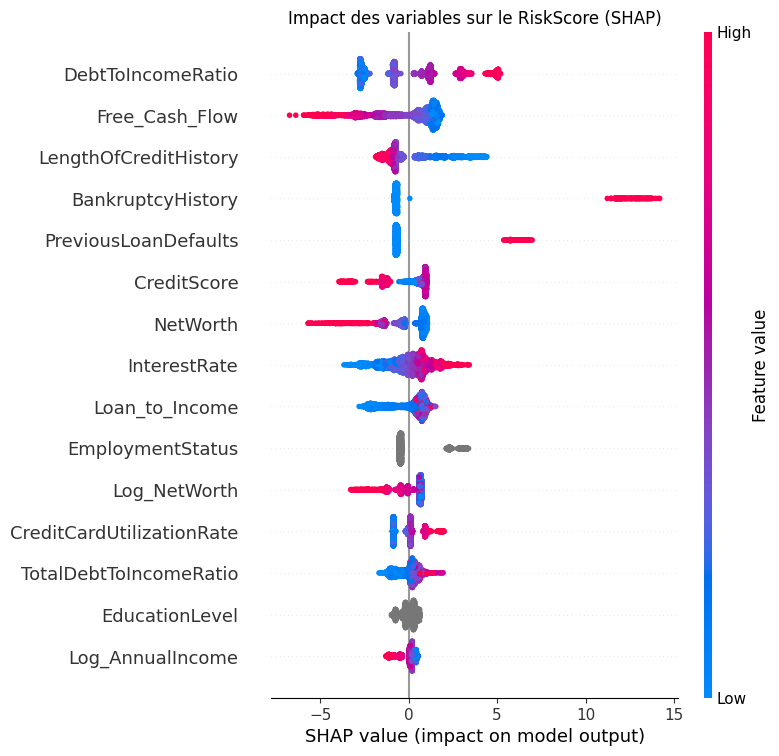

In [ ]:
import shap

print("--- Analyse SHAP (Interprétabilité) ---")

# CatBoost est compatible nativement avec SHAP
explainer = shap.TreeExplainer(best_catboost)
shap_values = explainer.shap_values(X_test)

plt.figure()
# Le summary plot montre l'impact positif/négatif
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("Impact des variables sur le RiskScore (SHAP)")
plt.show()

# Comparaison des modèles entre eux


--- COMPARAISON FINALE DES MODÈLES ---
{'Baseline (Linear)': array([46.69244494, 54.46610459, 57.24446719, ..., 50.64546371,
       45.61592857, 54.39804614], shape=(4000,)), 'CART': array([47.01666667, 55.28      , 53.38333333, ..., 51.79362416,
       48.21417323, 52.32380952], shape=(4000,)), 'Random Forest': array([48.03306054, 56.08838599, 55.74726152, ..., 52.3371258 ,
       48.47266164, 53.96388971], shape=(4000,)), 'XGBoost': array([45.173416, 52.677917, 58.72366 , ..., 52.13102 , 48.276276,
       54.16465 ], shape=(4000,), dtype=float32), 'CatBoost': array([45.09373093, 53.57236856, 59.93259611, ..., 52.23732487,
       48.33972412, 54.45072593], shape=(4000,))}

Tableau Récapitulatif des Performances :
                       RMSE       MAE        R²
Modèle                                         
CatBoost           2.257609  1.507419  0.915086
XGBoost            2.262170  1.504790  0.914742
Random Forest      2.959477  2.034077  0.854080
Baseline (Linear)  3.348115  2.68345

C:\Users\cleme\AppData\Local\Temp\ipykernel_108228\3830993550.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df_sorted.index, y='RMSE', data=results_df_sorted, palette='Reds_r')


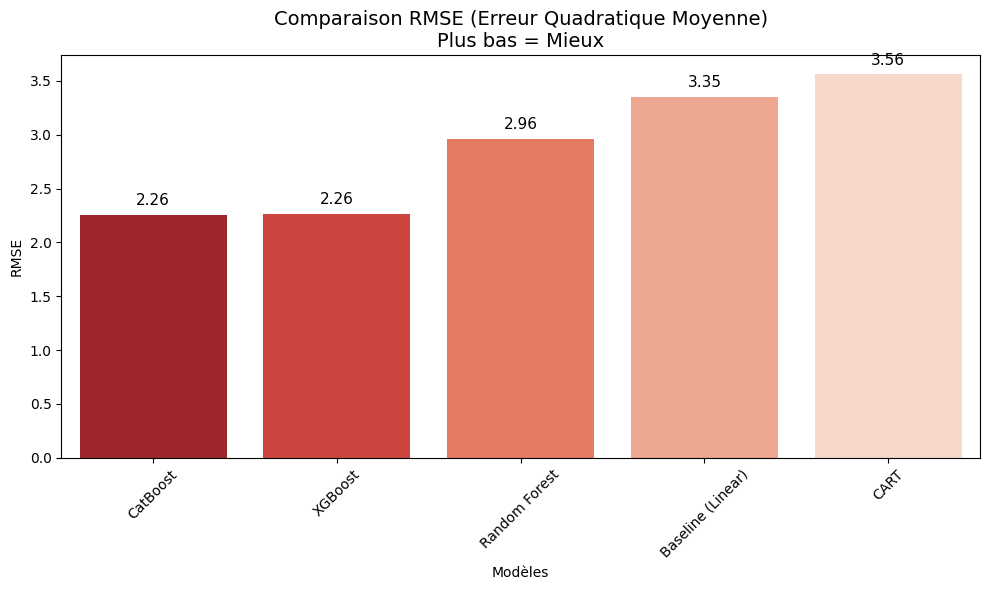

C:\Users\cleme\AppData\Local\Temp\ipykernel_108228\3830993550.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df_sorted.index, y='MAE', data=results_df_sorted, palette='Oranges_r')


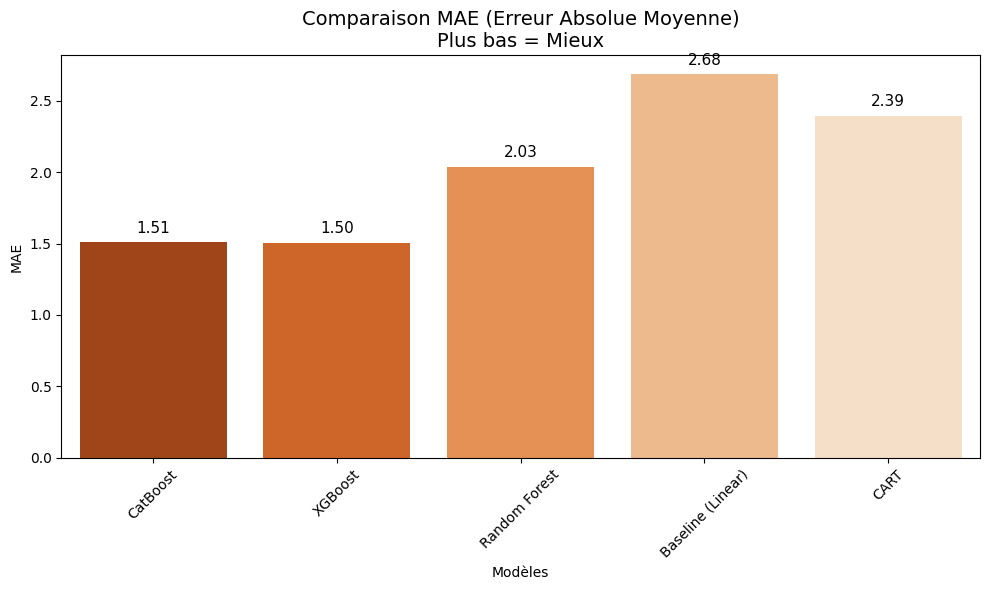

C:\Users\cleme\AppData\Local\Temp\ipykernel_108228\3830993550.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df_r2.index, y='R²', data=results_df_r2, palette='Greens_r')


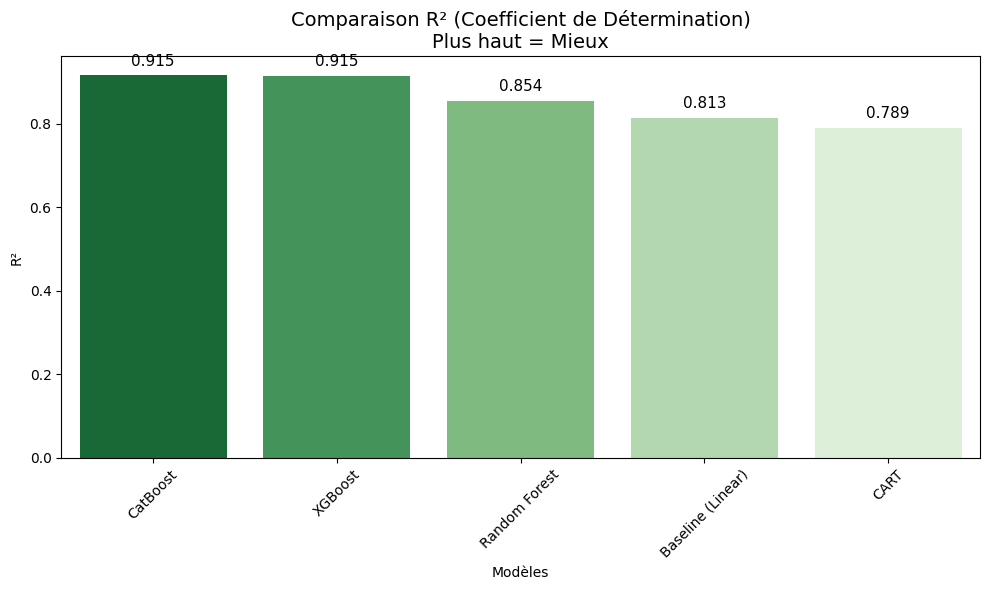

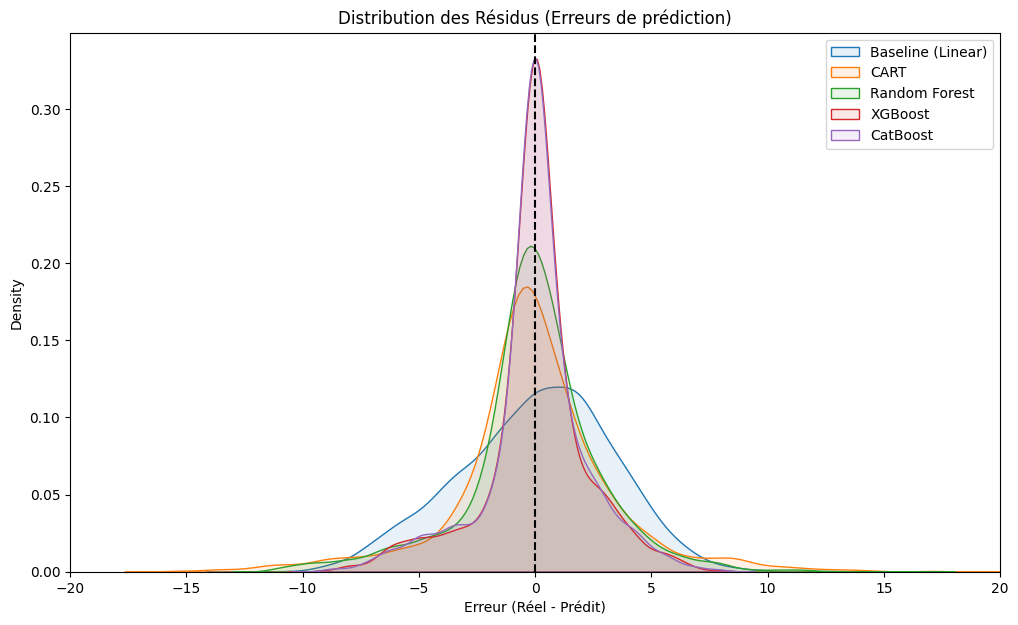

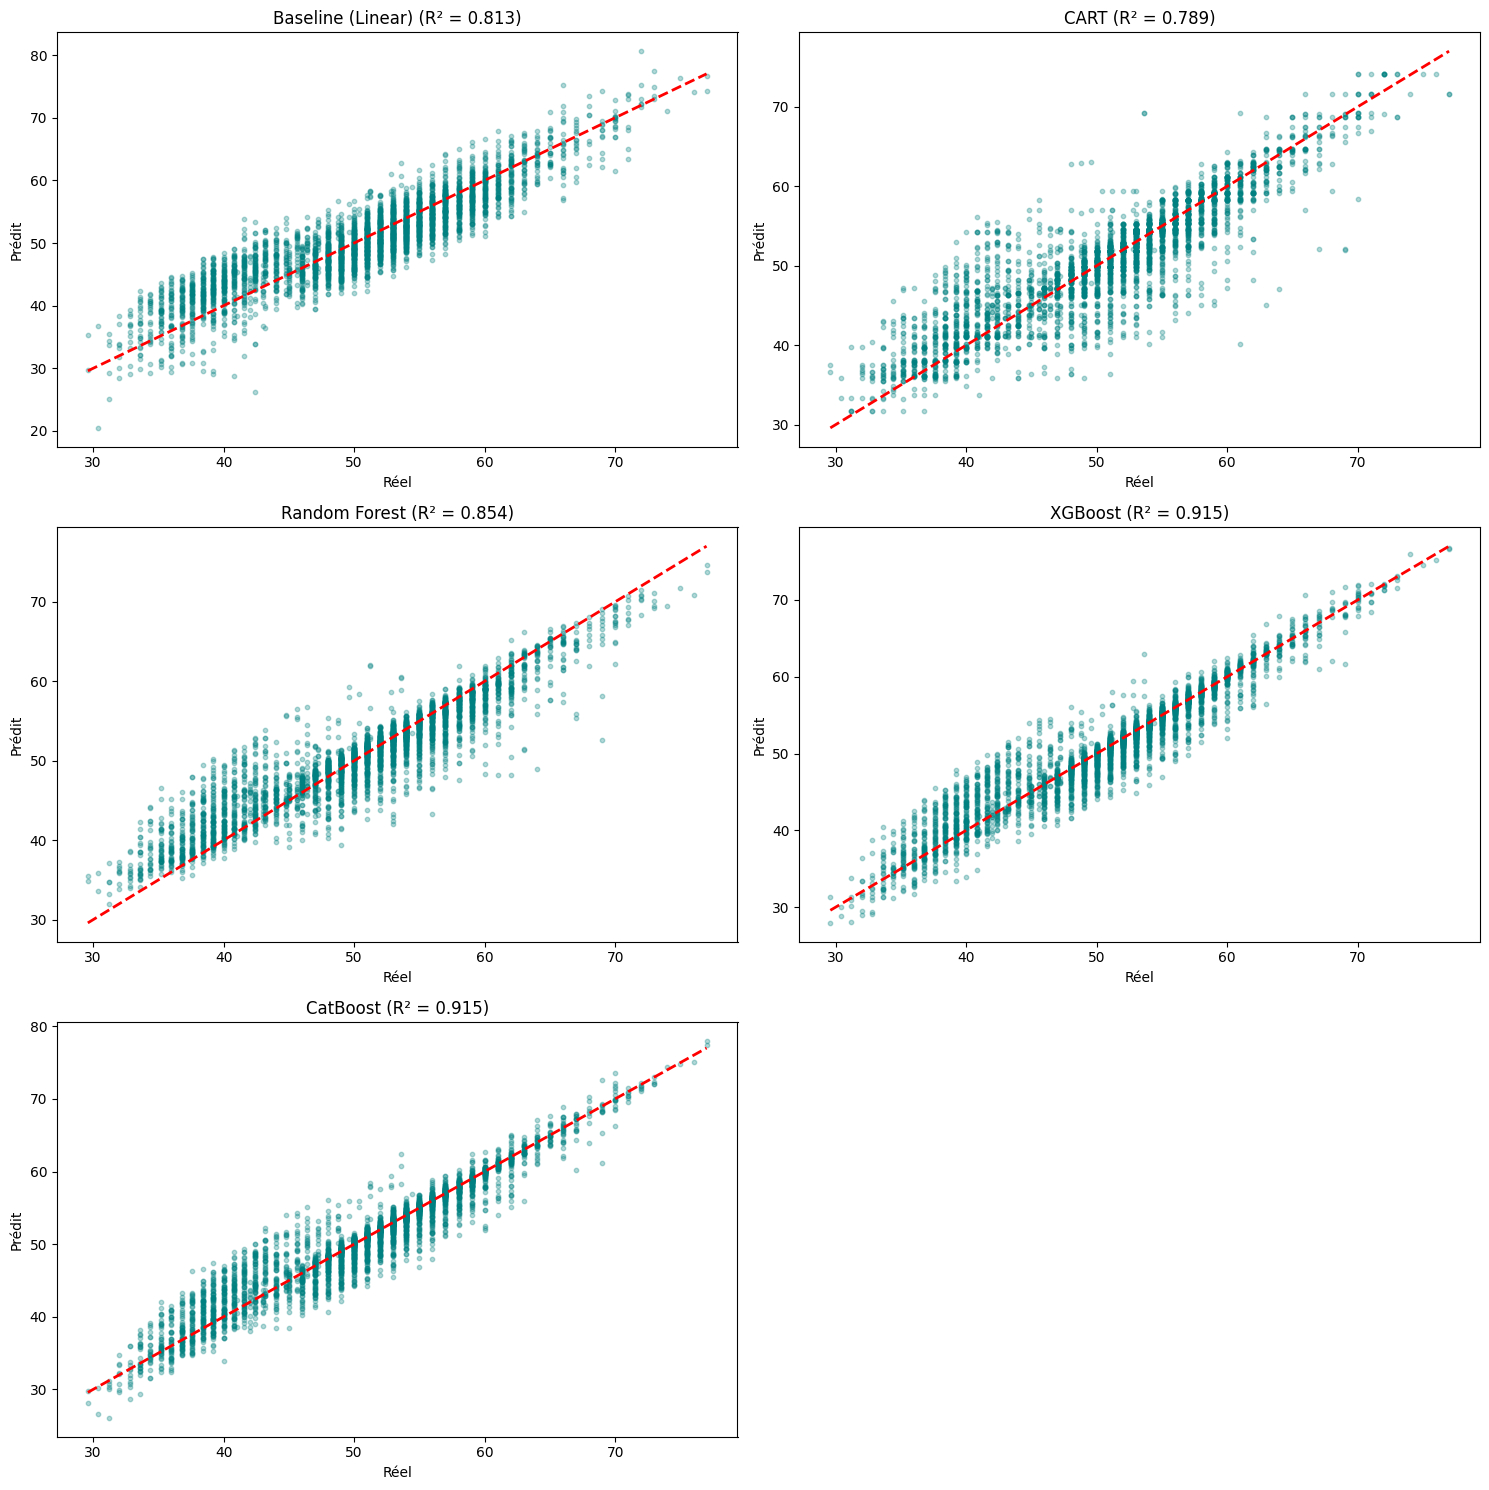

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("--- COMPARAISON FINALE DES MODÈLES ---")



# 1. Rassemblement des prédictions
# Assurez-vous que ces variables existent (sinon, commentez les lignes manquantes)
# Si vous n'avez pas gardé les variables, refaites un .predict() rapide
models_preds = {
    'Baseline (Linear)': y_pred_lr if 'y_pred_lr' in locals() else None,
    'CART': y_pred_cart if 'y_pred_cart' in locals() else None,
    'Random Forest': y_pred_rf if 'y_pred_rf' in locals() else None,
    'XGBoost': y_pred_xgb if 'y_pred_xgb' in locals() else None, # ou y_pred pour le dernier modèle
    'CatBoost': y_pred_catB if 'y_pred_catB' in locals() else None
}
print(models_preds)

# Filtrer les modèles non définis
models_preds = {k: v for k, v in models_preds.items() if v is not None}

# 2. Calcul des Métriques
results = []
for name, preds in models_preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Modèle': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})

results_df = pd.DataFrame(results).set_index('Modèle')
print("\nTableau Récapitulatif des Performances :")
print(results_df.sort_values(by='RMSE'))
results_df_sorted = results_df.sort_values(by='RMSE')

# --- Graphe 1.1 : RMSE ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=results_df_sorted.index, y='RMSE', data=results_df_sorted, palette='Reds_r')
plt.title('Comparaison RMSE (Erreur Quadratique Moyenne)\nPlus bas = Mieux', fontsize=14)
plt.ylabel('RMSE')
plt.xlabel('Modèles')
plt.xticks(rotation=45)
# Ajout des étiquettes
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# --- Graphe 1.2 : MAE ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=results_df_sorted.index, y='MAE', data=results_df_sorted, palette='Oranges_r')
plt.title('Comparaison MAE (Erreur Absolue Moyenne)\nPlus bas = Mieux', fontsize=14)
plt.ylabel('MAE')
plt.xlabel('Modèles')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# --- Graphe 1.3 : R² ---
# On trie différemment pour le R² (du meilleur au moins bon)
results_df_r2 = results_df.sort_values(by='R²', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=results_df_r2.index, y='R²', data=results_df_r2, palette='Greens_r')
plt.title('Comparaison R² (Coefficient de Détermination)\nPlus haut = Mieux', fontsize=14)
plt.ylabel('R²')
plt.xlabel('Modèles')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# ==========================================
# GRAPHE 2 : Distribution des Erreurs (Qui se trompe le moins ?)
# ==========================================
plt.figure(figsize=(12, 7))
for name, preds in models_preds.items():
    residuals = y_test - preds
    sns.kdeplot(residuals, label=f"{name}", fill=True, alpha=0.1)

plt.title("Distribution des Résidus (Erreurs de prédiction)")
plt.xlabel("Erreur (Réel - Prédit)")
plt.xlim(-20, 20) # Ajustez cette limite selon l'échelle de votre RiskScore
plt.axvline(0, color='black', linestyle='--')
plt.legend()
plt.show()

# ==========================================
# GRAPHE 3 : Nuage de Points Comparatif
# ==========================================
# On crée une grille de subplots selon le nombre de modèles
n_models = len(models_preds)
cols = 2
rows = (n_models + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, (name, preds) in enumerate(models_preds.items()):
    ax = axes[i]
    # Scatter plot
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='teal')
    # Ligne idéale
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    
    ax.set_title(f'{name} (R² = {results_df.loc[name, "R²"]:.3f})')
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')

# Cacher les axes vides s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()